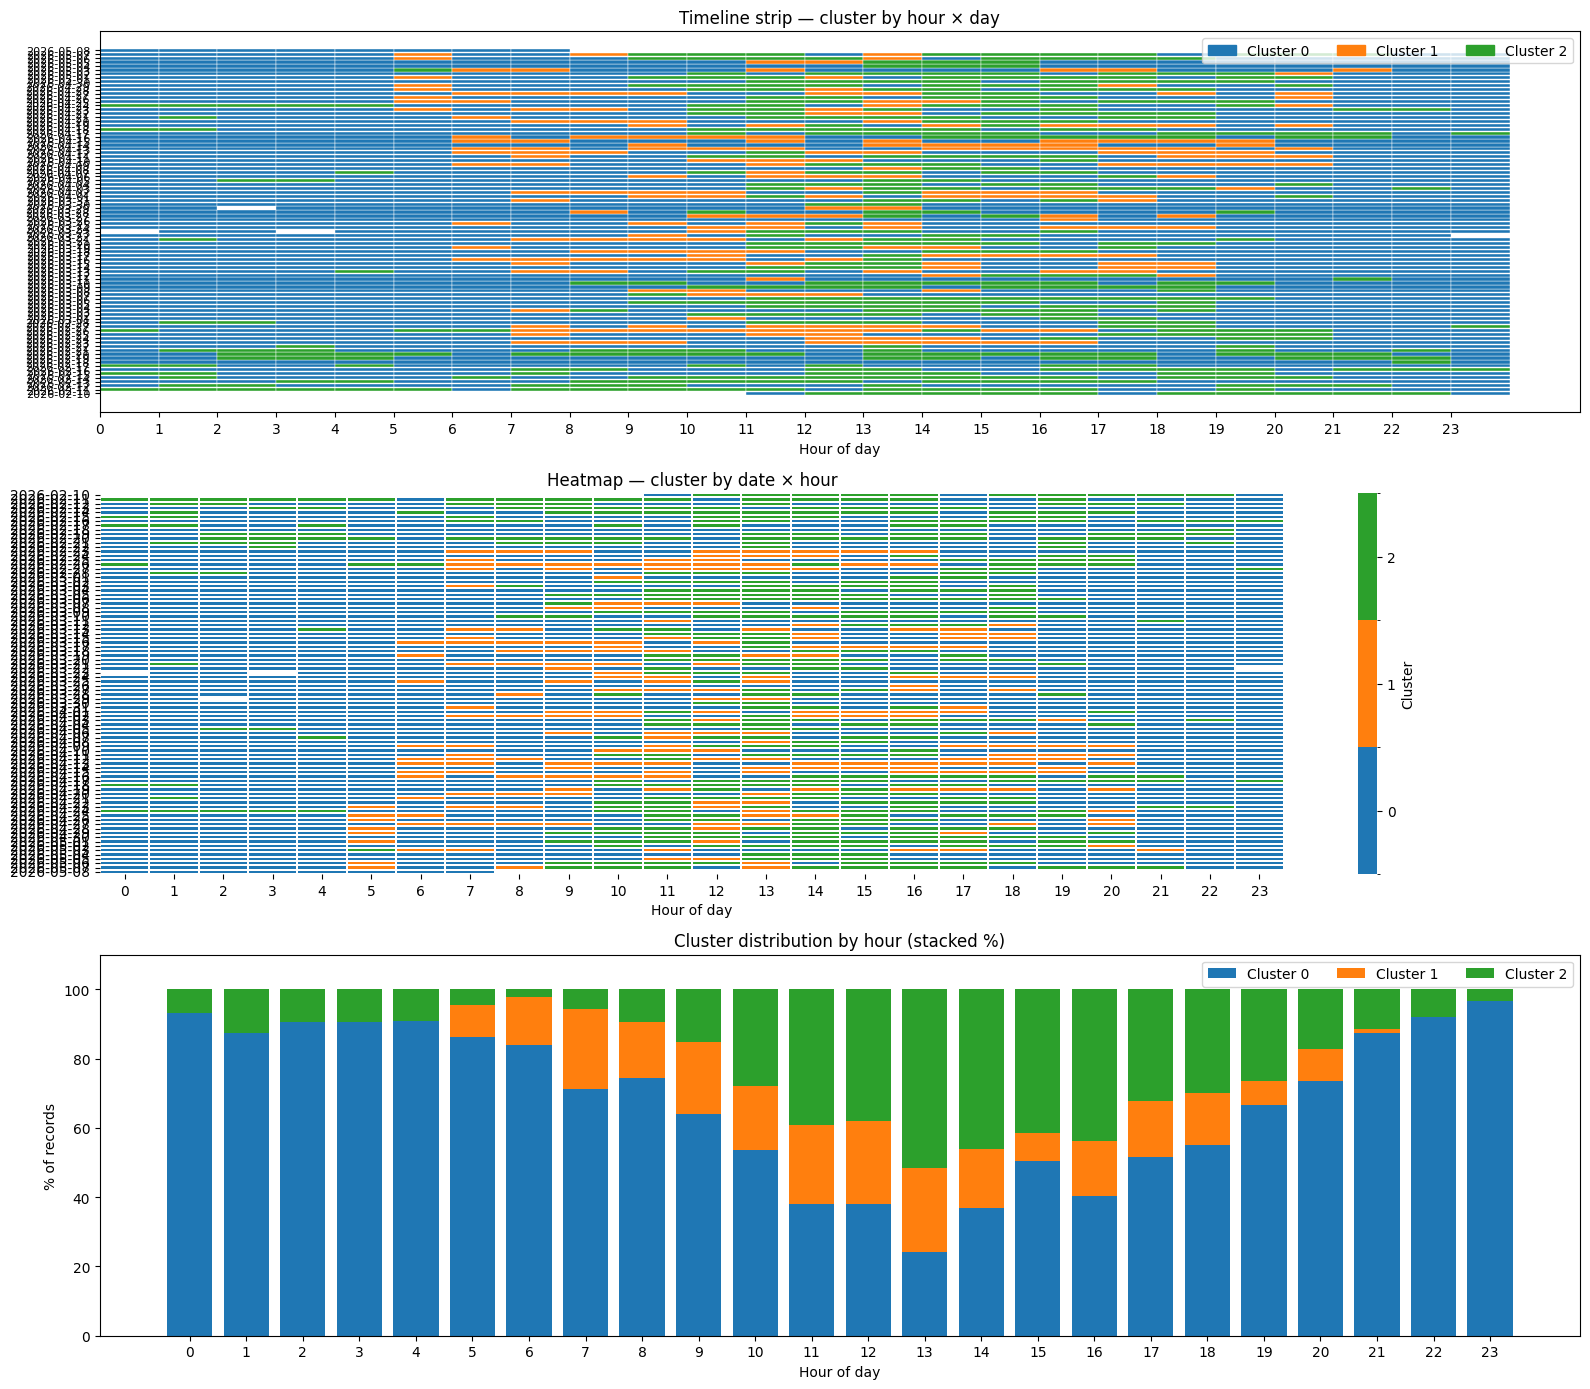

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

df = pd.read_csv("/Users/fangsiyu/Desktop/Kolding Hackathon 2026/cluster_h_kmean_k3.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert('Europe/Copenhagen')
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.day_name()

labels = sorted(df['cluster_label'].unique())
palette = dict(zip(labels, sns.color_palette('tab10', len(labels))))

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# 1. Timeline strip — 每小時一格，顏色 = cluster
ax = axes[0]
days = sorted(df['date'].unique())
day_idx = {d: i for i, d in enumerate(days)}

for _, row in df.iterrows():
    ax.barh(
        y=day_idx[row['date']],
        width=1,
        left=row['hour'],
        color=palette[row['cluster_label']],
        edgecolor='white', linewidth=0.3, height=0.8
    )

ax.set_yticks(range(len(days)))
ax.set_yticklabels([str(d) for d in days], fontsize=8)
ax.set_xticks(range(0, 24))
ax.set_xlabel('Hour of day')
ax.set_title('Timeline strip — cluster by hour × day')
legend_patches = [plt.Rectangle((0,0),1,1, color=palette[l], label=f'Cluster {l}') for l in labels]
ax.legend(handles=legend_patches, loc='upper right', ncol=len(labels))

# 2. Heatmap — 日期 × 小時
ax = axes[1]
pivot = df.pivot_table(index='date', columns='hour', values='cluster_label', aggfunc='first')
pivot = pivot.reindex(columns=range(24))

cmap = mcolors.ListedColormap([palette[l] for l in labels])
bounds = [l - 0.5 for l in labels] + [labels[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

sns.heatmap(
    pivot.astype(float), ax=ax, cmap=cmap, norm=norm,
    linewidths=0.3, linecolor='white',
    cbar_kws={'ticks': labels, 'label': 'Cluster'},
    yticklabels=[str(d) for d in pivot.index]
)
ax.set_title('Heatmap — cluster by date × hour')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')

# 3. 每小時 cluster 分布 — stacked bar
ax = axes[2]
hour_dist = (
    df.groupby(['hour', 'cluster_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(24), fill_value=0)
)
hour_dist_pct = hour_dist.div(hour_dist.sum(axis=1).replace(0, np.nan), axis=0) * 100

bottom = np.zeros(24)
for lbl in labels:
    if lbl in hour_dist_pct.columns:
        ax.bar(range(24), hour_dist_pct[lbl], bottom=bottom,
               color=palette[lbl], label=f'Cluster {lbl}', width=0.8)
        bottom += hour_dist_pct[lbl].fillna(0).values

ax.set_xticks(range(24))
ax.set_xlabel('Hour of day')
ax.set_ylabel('% of records')
ax.set_title('Cluster distribution by hour (stacked %)')
ax.legend(loc='upper right', ncol=len(labels))
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('cluster_viz.png', dpi=150, bbox_inches='tight')
plt.show()

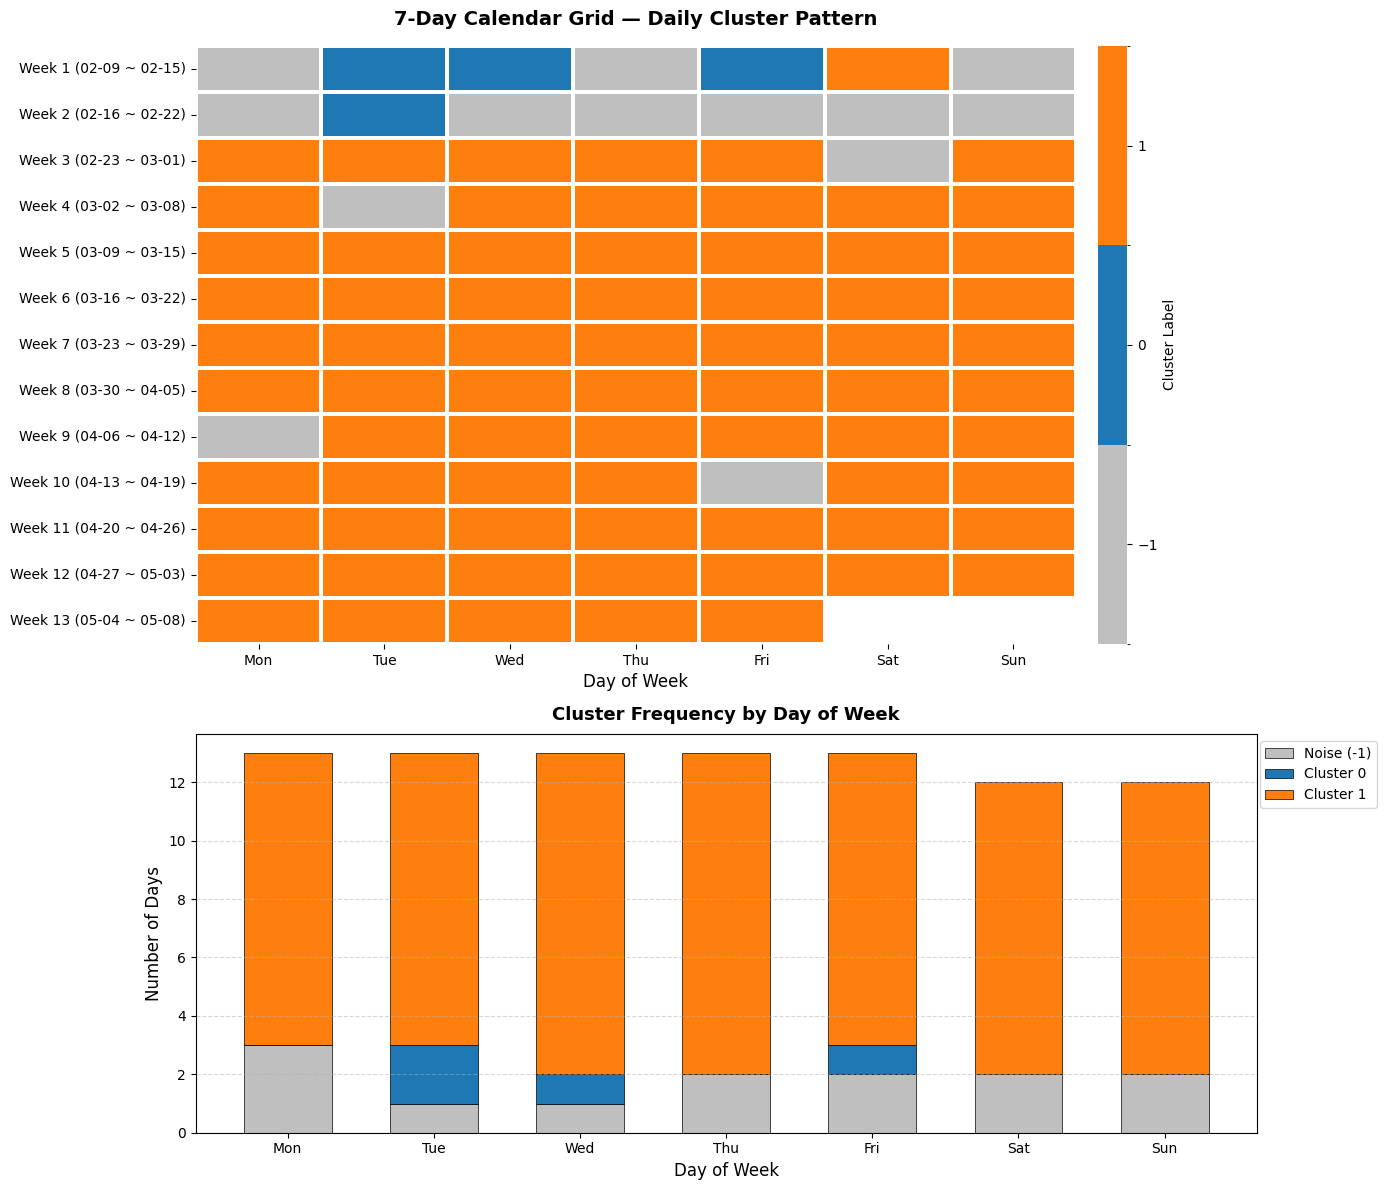

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

# 1. 讀取資料與時間轉換
df = pd.read_csv("/Users/fangsiyu/Desktop/Kolding Hackathon 2026/cluster_dbscan_k3.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert('Europe/Copenhagen')
df['date'] = df['timestamp'].dt.date

# 2. 【核心清洗】因為是天級分群，直接保留每天第一筆紀錄，將資料降維到「天」
daily_df = df.drop_duplicates(subset=['date']).sort_values('date').reset_index(drop=True)
daily_df['day_name'] = pd.to_datetime(daily_df['date']).dt.day_name()

# 3. 【關鍵：構建 7 天一週矩陣】
# 既然第一筆 (2026-02-09) 確定是 Monday，直接用 index 進行 7 的整除與取餘數
daily_df['week_idx'] = daily_df.index // 7
daily_df['day_idx'] = daily_df.index % 7  # 0=Mon, 1=Tue, ..., 6=Sun

# 自動生成 Y 軸的週標籤 (例如: Wk 1 (02-09 ~ 02-15))
week_labels = []
for w_idx in sorted(daily_df['week_idx'].unique()):
    week_days = daily_df[daily_df['week_idx'] == w_idx]
    start_date = week_days['date'].iloc[0].strftime('%m-%d')
    end_date = week_days['date'].iloc[-1].strftime('%m-%d')
    week_labels.append(f"Week {w_idx + 1} ({start_date} ~ {end_date})")

# 4. 建立精緻調色盤：將 -1 設為灰色，其餘群組使用鮮明色系
labels = sorted(daily_df['cluster_label'].unique())
base_palette = sns.color_palette('tab10', len(labels))
palette = {}
color_idx = 0
for l in labels:
    if l == -1:
        palette[l] = (0.75, 0.75, 0.75)  # 灰色代表 Noise
    else:
        palette[l] = base_palette[color_idx % len(base_palette)]
        color_idx += 1

# 5. 開始繪圖（改為 2 個子圖：上方為日曆矩陣，下方為星期累積分布）
fig, axes = plt.subplots(2, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [1.5, 1]})

# ---- 子圖 1：真正的 7 天單位日曆熱圖 (Calendar Heatmap) ----
ax = axes[0]
# 樞紐旋轉：Row 是第幾週，Column 是週一到週日 (0~6)
calendar_pivot = daily_df.pivot(index='week_idx', columns='day_idx', values='cluster_label')
calendar_pivot = calendar_pivot.reindex(columns=range(7))  # 確保固定 7 欄

cmap = mcolors.ListedColormap([palette[l] for l in labels])
bounds = [l - 0.5 for l in labels] + [labels[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 橫軸固定顯示星期
day_vector = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

sns.heatmap(
    calendar_pivot.astype(float), ax=ax, cmap=cmap, norm=norm,
    linewidths=1.5, linecolor='white', annot=False,
    cbar_kws={'ticks': labels, 'label': 'Cluster Label', 'pad': 0.02},
    xticklabels=day_vector,
    yticklabels=week_labels
)

ax.set_title('7-Day Calendar Grid — Daily Cluster Pattern', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('')
ax.tick_params(axis='both', labelsize=10)

# ---- 子圖 2：星期幾的分群統計分布 (Stacked Bar by Day of Week) ----
ax = axes[1]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# 統計每個星期幾中，各個 Cluster 出現的天數
day_dist = daily_df.groupby(['day_name', 'cluster_label']).size().unstack(fill_value=0)
day_dist = day_dist.reindex(day_order, fill_value=0)

bottom = np.zeros(7)
for lbl in labels:
    if lbl in day_dist.columns:
        ax.bar(
            day_vector, day_dist[lbl], bottom=bottom,
            color=palette[lbl], label='Noise (-1)' if lbl == -1 else f'Cluster {lbl}',
            edgecolor='black', linewidth=0.5, width=0.6
        )
        bottom += day_dist[lbl].values

ax.set_title('Cluster Frequency by Day of Week', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Number of Days', fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('cluster_daily_calendar_viz.png', dpi=150, bbox_inches='tight')
plt.show()